# Deep Deterministic Policy Gradient (DDPG)

**Penulis:** [amifunny](https://github.com/amifunny)<br>
**Tanggal dibuat:** 04/06/2020<br>
**Terakhir diubah:** 23/03/2024<br>
**Deskripsi:** Mengimplementasikan algoritma DDPG pada Masalah Pendulum Terbalik (Inverted Pendulum).

## Pendahuluan

**Deep Deterministic Policy Gradient (DDPG)** adalah algoritma *model-free off-policy* untuk
mempelajari aksi kontinu.

Algoritma ini menggabungkan ide-ide dari DPG (Deterministic Policy Gradient) dan DQN (Deep Q-Network).
Ia menggunakan *Experience Replay* dan *target networks* yang belajar secara lambat dari DQN, dan didasarkan pada
DPG, yang dapat beroperasi di atas ruang aksi kontinu.

Tutorial ini mengikuti makalah ini secara cermat -
[Continuous control with deep reinforcement learning](https://arxiv.org/abs/1509.02971)

## Masalah

Kita sedang mencoba menyelesaikan masalah kontrol klasik **Inverted Pendulum** (Pendulum Terbalik).
Dalam pengaturan ini, kita hanya bisa mengambil dua aksi: ayun kiri atau ayun kanan.

Apa yang membuat masalah ini menantang bagi Algoritma Q-Learning adalah aksinya
bersifat **kontinu**, bukan **diskrit**. Artinya, alih-alih menggunakan dua
aksi diskrit seperti `-1` atau `+1`, kita harus memilih dari aksi tak terbatas
mulai dari `-2` hingga `+2`.

## Teori Singkat

Sama seperti metode *Actor-Critic*, kita memiliki dua jaringan:

1. Actor (Aktor) - Mengusulkan sebuah aksi berdasarkan *state* (keadaan) yang diberikan.
2. Critic (Kritikus) - Memprediksi apakah aksi tersebut baik (nilai positif) atau buruk (nilai negatif)
berdasarkan *state* dan aksi yang diberikan.

DDPG menggunakan dua teknik lagi yang tidak ada dalam DQN asli:

**Pertama, ia menggunakan dua jaringan Target (Target networks).**

**Mengapa?** Karena ini menambah stabilitas pada pelatihan. Singkatnya, kita belajar dari target
yang diperkirakan dan jaringan Target diperbarui secara perlahan, sehingga menjaga target estimasi kita
tetap stabil.

Secara konseptual, ini seperti berkata, "Saya punya ide bagaimana cara memainkannya dengan baik,
saya akan mencobanya sebentar sampai saya menemukan sesuatu yang lebih baik",
berbeda dengan berkata "Saya akan belajar ulang cara memainkan seluruh permainan ini setelah setiap
langkah".
Lihat [jawaban StackOverflow](https://stackoverflow.com/a/54238556/13475679) ini.

**Kedua, ia menggunakan Experience Replay.**

Kita menyimpan daftar tuple `(state, action, reward, next_state)`, dan alih-alih
belajar hanya dari pengalaman baru-baru ini, kita belajar dari mengambil sampel (*sampling*) semua pengalaman kita
yang terkumpul sejauh ini.

Sekarang, mari kita lihat bagaimana implementasinya.

In [2]:
!python -m pip install keras tensorflow gymnasium matplotlib numpy gymnasium[classic_control] # NOTE : LAKUKAN JIKA ADA LIBRARY YANG KURANG
import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import tensorflow as tf
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import tensorflow as tf
print(f"Versi TensorFlow Anda: {tf.__version__}")

Versi TensorFlow Anda: 2.20.0


In [4]:
gpus = tf.config.experimental.list_physical_devices('GPU')

gpus = tf.config.experimental.list_physical_devices('GPU')
print("Daftar GPU yang Terdeteksi oleh TensorFlow:")
print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"Memory growth set for GPU: {gpu}")
    except RuntimeError as e:
        print(e)



Daftar GPU yang Terdeteksi oleh TensorFlow:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Memory growth set for GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


Kita menggunakan [Gymnasium](https://gymnasium.farama.org/) untuk membuat lingkungan (*environment*).
Kita akan menggunakan parameter `upper_bound` untuk menskalakan aksi kita nanti.

In [5]:
# Tentukan parameter `render_mode` untuk menampilkan upaya agen dalam jendela pop-up.
# Penjelasan: Membuat environment Pendulum. 'render_mode="human"' mengaktifkan tampilan visual/animasi saat dijalankan.
env = gym.make("Pendulum-v1", render_mode="human")

# Penjelasan: Mengambil jumlah dimensi state (informasi lingkungan) yang diterima agen (cos(theta), sin(theta), theta_dot).
num_states = env.observation_space.shape[0]
print("Ukuran Ruang State ->  {}".format(num_states))

# Penjelasan: Mengambil jumlah dimensi aksi yang bisa dilakukan agen (hanya 1, yaitu torsi gabungan).
num_actions = env.action_space.shape[0]
print("Ukuran Ruang Aksi ->  {}".format(num_actions))

# Penjelasan: Mengambil nilai maksimum (tertinggi) yang diizinkan untuk aksi (misal: +2.0).
upper_bound = env.action_space.high[0]
# Penjelasan: Mengambil nilai minimum (terendah) yang diizinkan untuk aksi (misal: -2.0).
lower_bound = env.action_space.low[0]

print("Nilai Maksimal Aksi ->  {}".format(upper_bound))
print("Nilai Minimal Aksi ->  {}".format(lower_bound))

Ukuran Ruang State ->  3
Ukuran Ruang Aksi ->  1
Nilai Maksimal Aksi ->  2.0
Nilai Minimal Aksi ->  -2.0


Untuk mengimplementasikan eksplorasi yang lebih baik oleh jaringan Actor, kita menggunakan perturbasi *noisy*,
secara khusus
sebuah **proses Ornstein-Uhlenbeck** untuk menghasilkan *noise*, seperti yang dijelaskan dalam makalah.
Proses ini mengambil sampel *noise* dari distribusi normal yang berkorelasi.

In [6]:
class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        # Penjelasan: Menginisialisasi parameter untuk proses noise
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        # Rumus diambil dari https://www.wikipedia.org/wiki/Ornstein-Uhlenbeck_process
        # Penjelasan: Menghitung nilai noise 'x' saat ini.
        # Rumus OU Noise memiliki komponen "Mean Reversion" (kembali ke rata-rata).
        # x = x_prev + theta * (mean - x_prev) * dt + noise
        x = (
            self.x_prev
            + self.theta * (self.mean - self.x_prev) * self.dt # TODO 1: Isi dengan variabel rata-rata tujuan
            + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
        )

        # Simpan x ke dalam variabel state sebelumnya
        # Penjelasan: Kita perlu menyimpan nilai x saat ini agar bisa digunakan
        # sebagai 'x_prev' pada pemanggilan fungsi berikutnya.
        self.x_prev = x # TODO 2: Update state noise sebelumnya
        
        return x

    def reset(self):
        # Penjelasan: Mengatur ulang noise ke kondisi awal
        if self.x_initial is not None:
            self.x_prev = self.x_initial
        else:
            self.x_prev = np.zeros_like(self.mean)

Kelas `Buffer` mengimplementasikan *Experience Replay*.

---
![Algorithm](https://i.imgur.com/mS6iGyJ.jpg)
---


**Critic loss** - *Mean Squared Error* dari `y - Q(s, a)`
di mana `y` adalah pengembalian yang diharapkan (*expected return*) seperti yang dilihat oleh jaringan Target,
dan `Q(s, a)` adalah nilai aksi yang diprediksi oleh jaringan Critic. `y` adalah target bergerak
yang coba dicapai oleh model kritikus; kita membuat target ini
stabil dengan memperbarui model Target secara perlahan.

**Actor loss** - Ini dihitung menggunakan rata-rata nilai yang diberikan oleh jaringan Critic
untuk aksi yang diambil oleh jaringan Actor. Kita berusaha untuk memaksimalkan nilai ini.

Oleh karena itu kita memperbarui jaringan Actor agar ia menghasilkan aksi yang mendapatkan
nilai prediksi maksimum seperti yang dilihat oleh Critic, untuk *state* tertentu.

In [7]:
# --- HYPERPARAMETERS (Gunakan nama variabel di sini untuk menjawab) ---
std_dev = 0.2
critic_lr = 0.002
actor_lr = 0.001
total_episodes = 100
gamma = 0.99  # Faktor diskon (Discount Factor) untuk reward masa depan
tau = 0.005   # Laju update target network
# ---------------------------------------------------------------------------

class Buffer:
    def __init__(self, buffer_capacity=100000, batch_size=64):
        # Jumlah maksimal "pengalaman" yang disimpan
        # Penjelasan: Kapasitas maksimum memori. Jika penuh, data terlama akan ditimpa.
        self.buffer_capacity = buffer_capacity
        # Jumlah tuple untuk dilatih per langkah.
        # Penjelasan: Berapa banyak data yang diambil sekaligus untuk satu kali update bobot (training step).
        self.batch_size = batch_size

        # Ini memberitahu kita berapa kali record() telah dipanggil.
        self.buffer_counter = 0

        # Alih-alih daftar tuple seperti konsep exp.replay pada umumnya
        # Kita menggunakan np.arrays yang berbeda untuk setiap elemen tuple
        # Penjelasan: Menggunakan numpy array jauh lebih efisien secara memori dan kecepatan akses dibanding list Python biasa.
        self.state_buffer = np.zeros((self.buffer_capacity, num_states))
        self.action_buffer = np.zeros((self.buffer_capacity, num_actions))
        self.reward_buffer = np.zeros((self.buffer_capacity, 1))
        self.next_state_buffer = np.zeros((self.buffer_capacity, num_states))

    # Menerima tuple observasi (s,a,r,s') sebagai input
    def record(self, obs_tuple):
        # Set index ke nol jika buffer_capacity terlampaui,
        # mengganti catatan lama
        # Penjelasan: Menggunakan operasi modulo (%) untuk membuat 'Circular Buffer'. Jika counter > kapasitas, index kembali ke 0.
        index = self.buffer_counter % self.buffer_capacity # TODO 1: Isi dengan operator matematika yang tepat (Modulo)

        self.state_buffer[index] = obs_tuple[0]
        self.action_buffer[index] = obs_tuple[1]
        self.reward_buffer[index] = obs_tuple[2]
        self.next_state_buffer[index] = obs_tuple[3]

        self.buffer_counter += 1

    # Eager execution diaktifkan secara default di TensorFlow 2. Dekorasi dengan tf.function memungkinkan
    # TensorFlow untuk membangun grafik statis dari logika dan komputasi dalam fungsi kita.
    # Ini memberikan percepatan besar untuk blok kode yang berisi banyak operasi TensorFlow kecil seperti ini.
    # Penjelasan: @tf.function mengkompilasi fungsi ini menjadi graph C++ yang sangat cepat, penting untuk loop training.
    @tf.function
    def update(
        self,
        state_batch,
        action_batch,
        reward_batch,
        next_state_batch,
    ):
        # Melatih dan memperbarui jaringan Actor & Critic.
        # Lihat Kode Pseudo.
        with tf.GradientTape() as tape:
            # Penjelasan: Target Actor memprediksi aksi selanjutnya (tanpa noise).
            target_actions = target_actor(next_state_batch, training=True)
            
            # Penjelasan: Menghitung target Q-value (y). Rumus Bellman: Reward + Discount Factor * Prediksi Q dari state selanjutnya.
            # Gunakan variabel dari daftar Hyperparameters di atas.
            y = reward_batch + gamma * target_critic(
                [next_state_batch, target_actions], training=True
            ) # TODO 2: Isi dengan nama variabel hyperparameter untuk faktor diskon

            # Penjelasan: Critic model memprediksi Q-value saat ini berdasarkan state dan aksi yang diambil.
            critic_value = critic_model([state_batch, action_batch], training=True)
            
            # Penjelasan: Menghitung loss Critic (Mean Squared Error) antara Target (y) dan Prediksi (critic_value).
            critic_loss = keras.ops.mean(keras.ops.square(y - critic_value))

        # Penjelasan: Menghitung gradien dan memperbarui bobot Critic agar prediksinya makin akurat.
        critic_grad = tape.gradient(critic_loss, critic_model.trainable_variables)
        critic_optimizer.apply_gradients(
            zip(critic_grad, critic_model.trainable_variables)
        )

        with tf.GradientTape() as tape:
            # Penjelasan: Actor memprediksi aksi baru untuk state saat ini.
            actions = actor_model(state_batch, training=True)
            
            # Penjelasan: Critic menilai seberapa bagus aksi yang baru saja diprediksi Actor.
            critic_value = critic_model([state_batch, actions], training=True)
            
            # Menggunakan `-value` karena kita ingin memaksimalkan nilai yang diberikan
            # oleh critic untuk aksi kita
            # Penjelasan: Gradient Descent meminimalkan loss. Untuk Memaksimalkan nilai, kita Minimalkan Negatif-nya (-value).
            actor_loss = -keras.ops.mean(critic_value) # TODO 3: Isi dengan simbol matematika (+ atau -)

        # Penjelasan: Menghitung gradien dan memperbarui bobot Actor untuk menghasilkan aksi yang bernilai lebih tinggi.
        actor_grad = tape.gradient(actor_loss, actor_model.trainable_variables)
        actor_optimizer.apply_gradients(
            zip(actor_grad, actor_model.trainable_variables)
        )

    # Kita menghitung loss dan memperbarui parameter
    def learn(self):
        # Dapatkan rentang sampling
        # Penjelasan: Memastikan kita tidak mengambil sample dari area buffer yang masih kosong (jika baru mulai belajar).
        record_range = min(self.buffer_counter, self.buffer_capacity)
        
        # Ambil sampel indeks secara acak
        # Penjelasan: Random sampling memutus korelasi antar data berurutan, membuat training lebih stabil.
        batch_indices = np.random.choice(record_range, self.batch_size)

        # Konversi ke tensor
        # Penjelasan: TensorFlow membutuhkan format Tensor, bukan numpy array, untuk perhitungan GPU.
        state_batch = keras.ops.convert_to_tensor(self.state_buffer[batch_indices])
        action_batch = keras.ops.convert_to_tensor(self.action_buffer[batch_indices])
        reward_batch = keras.ops.convert_to_tensor(self.reward_buffer[batch_indices])
        reward_batch = keras.ops.cast(reward_batch, dtype="float32")
        next_state_batch = keras.ops.convert_to_tensor(
            self.next_state_buffer[batch_indices]
        )

        self.update(state_batch, action_batch, reward_batch, next_state_batch)


# Ini memperbarui parameter target secara perlahan
# Berdasarkan laju `tau`, yang jauh lebih kecil dari satu.
# Penjelasan: Soft Update. Bobot target tidak langsung dicopy 100%, tapi digeser sedikit demi sedikit (tau) mendekati bobot asli.
# Ini mencegah target berubah terlalu drastis yang bisa membuat training tidak stabil.
def update_target(target, original, tau):
    target_weights = target.get_weights()
    original_weights = original.get_weights()

    for i in range(len(target_weights)):
        target_weights[i] = original_weights[i] * tau + target_weights[i] * (1 - tau)

    target.set_weights(target_weights)

Di sini kita mendefinisikan jaringan Actor dan Critic. Ini adalah model Dense dasar
dengan aktivasi `ReLU`.

Catatan: Kita membutuhkan inisialisasi untuk layer terakhir dari Actor agar berada di antara
`-0.003` dan `0.003` karena hal ini mencegah kita mendapatkan nilai output `1` atau `-1` pada
tahap awal, yang akan menekan gradien kita menjadi nol (*squash gradients*),
karena kita menggunakan aktivasi `tanh`.

In [11]:
def get_actor():
    # Inisialisasi bobot antara -3e-3 dan 3-e3
    last_init = keras.initializers.RandomUniform(minval=-0.003, maxval=0.003)

    inputs = layers.Input(shape=(num_states,))
    out = layers.Dense(256, activation="relu")(inputs)
    out = layers.Dense(256, activation="relu")(out)
    
    # Penjelasan: Output layer membutuhkan fungsi aktivasi yang bisa menghasilkan nilai negatif dan positif.
    # Pendulum harus bisa bergerak ke kiri (negatif) dan ke kanan (positif).
    # Clue: Rentang Relu (0 s/d inf), Sigmoid (0 s/d 1), Tanh (-1 s/d 1). Pilih yang tepat!
    outputs = layers.Dense(1, activation="tanh", kernel_initializer=last_init)(out) # TODO 1: Isi nama fungsi aktivasi

    # Batas atas kita adalah 2.0 untuk Pendulum.
    outputs = outputs * upper_bound
    model = keras.Model(inputs, outputs)
    return model


def get_critic():
    # State sebagai input
    state_input = layers.Input(shape=(num_states,))
    state_out = layers.Dense(16, activation="relu")(state_input)
    state_out = layers.Dense(32, activation="relu")(state_out)

    # Aksi sebagai input
    action_input = layers.Input(shape=(num_actions,))
    action_out = layers.Dense(32, activation="relu")(action_input)

    # Keduanya dilewatkan melalui layer terpisah sebelum digabungkan
    # Penjelasan: Critic menilai kombinasi (State + Action). Kita perlu menggabungkan kedua input ini.
    # Clue: Dalam bahasa Inggris, "Menggabungkan" atau "Menyambung" string/array disebut 'Concatenate'.
    # Gunakan nama layer Keras yang sesuai dengan kata tersebut.
    concat = layers.Concatenate()([state_out, action_out]) # TODO 2: Isi dengan nama layer Keras

    out = layers.Dense(256, activation="relu")(concat)
    out = layers.Dense(256, activation="relu")(out)
    
    # Penjelasan: Output Critic adalah Q-Value (sebuah Skor/Nilai).
    # Q-Value bukanlah probabilitas klasifikasi (seperti membedakan 10 jenis gambar), tapi hanya SATU angka skor.
    # Berapa jumlah neuron yang dibutuhkan untuk mengeluarkan 1 angka saja?
    outputs = layers.Dense(1)(out) # TODO 3: Isi dengan angka integer (jumlah neuron)

    # Outputkan nilai tunggal untuk pasangan state-action yang diberikan
    model = keras.Model([state_input, action_input], outputs)

    return model

`policy()` mengembalikan sebuah aksi yang diambil sampelnya dari jaringan Actor kita ditambah sedikit *noise* untuk
eksplorasi.

In [12]:
def policy(state, noise_object):
    # Penjelasan: Mengambil aksi murni dari model Actor berdasarkan state saat ini. 'squeeze' menghapus dimensi batch yang tidak perlu.
    sampled_actions = keras.ops.squeeze(actor_model(state))
    
    # Penjelasan: Menghasilkan noise eksplorasi (Ornstein-Uhlenbeck) untuk langkah ini.
    noise = noise_object()
    
    # Menambahkan noise ke aksi
    # Penjelasan: Menambahkan noise ke aksi deterministik. Ini memaksa agen untuk mencoba variasi aksi baru (Eksplorasi).
    sampled_actions = sampled_actions.numpy() + noise

    # Kita memastikan aksi berada dalam batas
    # Penjelasan: Menjepit (clipping) nilai aksi agar tidak melebihi batas fisik environment (misal: antara -2.0 dan 2.0). 
    # Clue: Cari nama fungsi di library Numpy (np) yang tugasnya "menjepit" atau membatasi nilai array agar tetap berada di antara batas bawah dan batas atas.
    # Nama fungsinya sama dengan kata bahasa Inggris untuk "Menjepit" yang disebutkan di penjelasan di atas.
    legal_action = np.clip(sampled_actions, lower_bound, upper_bound) # TODO 1: Isi nama fungsi Numpy

    return [np.squeeze(legal_action)]

## Training hyperparameters

In [13]:
std_dev = 0.2
# Penjelasan: Inisialisasi objek noise Ornstein-Uhlenbeck.
ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

# Penjelasan: Membuat insturmen model Actor dan Critic utama (yang akan dilatih).
actor_model = get_actor()
critic_model = get_critic()

# Penjelasan: Membuat instrumen model Target Actor dan Target Critic (untuk perhitungan loss yang stabil).
target_actor = get_actor()
target_critic = get_critic()

# Membuat bobot sama pada awalnya
# Penjelasan: Menyalin bobot awal dari model utama ke model target agar start-nya sama.
# Clue: Kita mengambil bobot dari actor_model (get_weights), lalu kita harus MENYETEL bobot tersebut ke target_actor.
# Bahasa Inggris "Menyetel" atau "Mengatur" adalah 'Set'.
target_actor.set_weights(actor_model.get_weights()) # TODO 1: Isi nama method Keras untuk mengatur bobot
target_critic.set_weights(critic_model.get_weights())

# Learning rate untuk model actor-critic
critic_lr = 0.002
actor_lr = 0.001

# Penjelasan: Menentukan optimizer (Adam) dengan learning rate masing-masing.
critic_optimizer = keras.optimizers.Adam(critic_lr)
actor_optimizer = keras.optimizers.Adam(actor_lr)

total_episodes = 100

# Faktor diskon untuk reward masa depan
# Penjelasan: Variabel ini menentukan seberapa penting reward masa depan. 
# Nilai 0.99 berarti agen sangat peduli dampak jangka panjang.
# Clue: Dalam rumus matematika Reinforcement Learning, faktor diskon hampir selalu dilambangkan dengan huruf Yunani 'γ'.
# Apa nama variabel (ejaan latin) dari huruf 'γ' tersebut?
gamma = 0.99 # TODO 2: Isi nama variabel untuk Discount Factor

# Digunakan untuk memperbarui jaringan target
# Penjelasan: Variabel ini adalah laju "Soft Update". 
# 0.005 berarti target network hanya berubah 0.5% mendekati network utama di setiap langkah.
# Clue: Dalam paper DDPG, parameter soft update dilambangkan dengan huruf Yunani 'τ'.
# Apa nama variabel (ejaan latin) dari huruf 'τ' tersebut? (Lihat komentar penjelasan di atasnya kalau bingung!)
tau = 0.005 # TODO 3: Isi nama variabel untuk Soft Update rate

# Penjelasan: Inisialisasi Replay Buffer dengan kapasitas 50.000 data dan batch size 64.
buffer = Buffer(50000, 64)

Sekarang kita mengimplementasikan loop pelatihan utama kita, dan melakukan iterasi pada setiap episode.
Kita mengambil sampel aksi menggunakan `policy()` dan melatih dengan `learn()` pada setiap langkah waktu,
bersamaan dengan memperbarui jaringan Target dengan laju `tau`.

/home/naomi/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode * 0 * Rata-rata Reward adalah ==> -1776.936901169287
Episode * 1 * Rata-rata Reward adalah ==> -1444.0417199201825
Episode * 2 * Rata-rata Reward adalah ==> -1533.8826013263385
Episode * 3 * Rata-rata Reward adalah ==> -1395.5693079191544
Episode * 4 * Rata-rata Reward adalah ==> -1420.761472722515
Episode * 5 * Rata-rata Reward adalah ==> -1431.2510047650865
Episode * 6 * Rata-rata Reward adalah ==> -1402.6394888700142
Episode * 7 * Rata-rata Reward adalah ==> -1406.8127707072567
Episode * 8 * Rata-rata Reward adalah ==> -1391.7566834928373
Episode * 9 * Rata-rata Reward adalah ==> -1387.7000429903242
Episode * 10 * Rata-rata Reward adalah ==> -1388.101266454851
Episode * 11 * Rata-rata Reward adalah ==> -1347.637964687681
Episode * 12 * Rata-rata Reward adalah ==> -1299.539755872814
Episode * 13 * Rata-rata Reward adalah ==> -1235.9557647867355
Episode * 14 * Rata-rata Reward adalah ==> -1204.1442830949932
Episode * 15 * Rata-rata Reward adalah ==> -1181.5820421741607
Episode

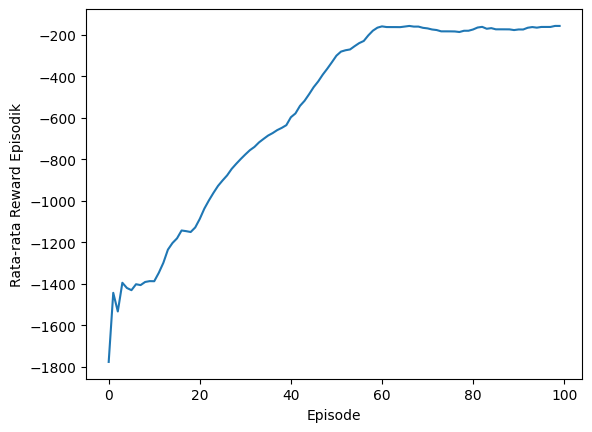

In [14]:
# Untuk menyimpan riwayat reward setiap episode
ep_reward_list = []
# Untuk menyimpan riwayat rata-rata reward dari beberapa episode terakhir
avg_reward_list = []

# Loop utama untuk setiap episode permainan.
for ep in range(total_episodes):
    # Penjelasan: Reset lingkungan ke kondisi awal untuk memulai episode baru.
    prev_state, _ = env.reset()
    episodic_reward = 0

    while True:
        # Penjelasan: Mengubah state menjadi Tensor dan menambah dimensi batch.
        tf_prev_state = keras.ops.expand_dims(
            keras.ops.convert_to_tensor(prev_state), 0
        )

        # Penjelasan: Actor memilih aksi berdasarkan state saat ini (ditambah noise).
        action = policy(tf_prev_state, ou_noise)
        
        # Menerima state dan reward dari lingkungan.
        # Penjelasan: Fungsi utama Gym untuk mengeksekusi aksi ke dalam lingkungan.
        # Fungsi ini mengembalikan tuple: (state, reward, done, truncated, info).
        # Clue: Bahasa Inggris dari "Langkah". Ini adalah method paling umum di library Gym.
        state, reward, done, truncated, _ = env.step(action) # TODO 1: Isi nama method environment

        # Penjelasan: Menyimpan pengalaman (tuple) ini ke dalam Replay Buffer.
        # Kita sudah membuat method ini di dalam 'class Buffer' sebelumnya.
        # Clue: Cek kembali definisi 'class Buffer' di atas. Apa nama fungsi untuk menyimpan data (s,a,r,s')?
        buffer.record((prev_state, action, reward, state)) # TODO 2: Isi nama method dari objek buffer

        episodic_reward += reward

        # Penjelasan: Proses belajar (Update bobot).
        buffer.learn()

        # Penjelasan: Melakukan Soft Update ke jaringan target.
        update_target(target_actor, actor_model, tau)
        update_target(target_critic, critic_model, tau)

        # Akhiri episode ini ketika `done` atau `truncated` bernilai True
        if done or truncated:
            # Penjelasan: Perintah Python untuk menghentikan paksa loop 'while' saat ini
            # dan lanjut ke episode (loop 'for') berikutnya.
            break # TODO 3: Isi syntax Python untuk keluar dari loop
            
        prev_state = state

    ep_reward_list.append(episodic_reward)

    # Rata-rata dari 40 episode terakhir
    avg_reward = np.mean(ep_reward_list[-40:])
    print("Episode * {} * Rata-rata Reward adalah ==> {}".format(ep, avg_reward))
    avg_reward_list.append(avg_reward)

# Memplot grafik
plt.plot(avg_reward_list)
plt.xlabel("Episode")
plt.ylabel("Rata-rata Reward Episodik")
plt.show()

Jika pelatihan berjalan dengan benar, rata-rata *reward* episodik akan meningkat seiring waktu.

Jangan ragu untuk mencoba *learning rate*, nilai `tau`, dan arsitektur yang berbeda untuk
jaringan Actor dan Critic.

Masalah Pendulum Terbalik memiliki kompleksitas rendah, tetapi DDPG bekerja sangat baik pada banyak masalah
lainnya.

Lingkungan hebat lainnya untuk mencoba ini adalah `LunarLander-v2` kontinu, tetapi akan membutuhkan
lebih banyak episode untuk mendapatkan hasil yang baik.

In [15]:
# Simpan bobot
# Penjelasan: Menyimpan bobot model yang sudah dilatih ke file .h5 agar bisa digunakan kembali tanpa perlu training ulang.
# Clue: Kita ingin MENYIMPAN (Save) BOBOT (Weights). 
# Dalam library Keras, nama method biasanya diambil langsung dari bahasa Inggrisnya, dipisahkan dengan underscore (_).
actor_model.save_weights("pendulum_actor.weights.h5") # TODO 1: Isi nama method untuk menyimpan bobot
critic_model.save_weights("pendulum_critic.weights.h5") # TODO 1

target_actor.save_weights("pendulum_target_actor.weights.h5") # TODO 1
target_critic.save_weights("pendulum_target_critic.weights.h5") # TODO 1

In [16]:
#INi supaya bisa close gamenya
env.close()

#notes: 19 todo * 5 = 95, 5 sisanya jika lengkap semua maka 100.

Before Training:

![before_img](https://i.imgur.com/ox6b9rC.gif)

After 100 episodes:

![after_img](https://i.imgur.com/eEH8Cz6.gif)